In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
train_data = pd.read_csv("data/train.csv")

In [5]:
train_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


array([[<Axes: title={'center': 'pressure'}>,
        <Axes: title={'center': 'maxtemp'}>,
        <Axes: title={'center': 'mintemp'}>],
       [<Axes: title={'center': 'dewpoint'}>,
        <Axes: title={'center': 'winddirection'}>,
        <Axes: title={'center': 'windspeed'}>],
       [<Axes: title={'center': 'cloud'}>,
        <Axes: title={'center': 'sunshine'}>, <Axes: >]], dtype=object)

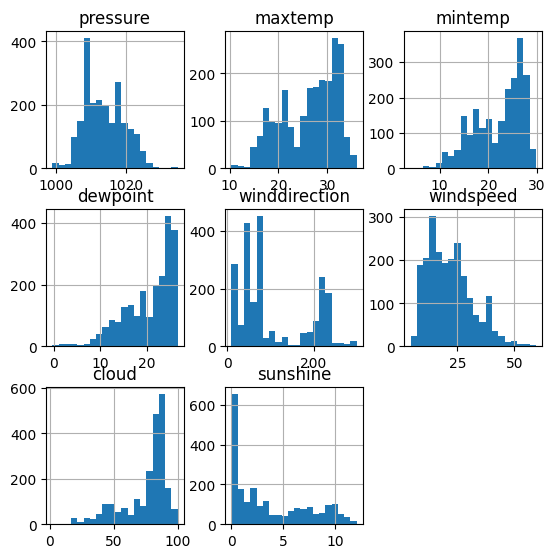

In [6]:
useful_cols = ["pressure", "maxtemp", "mintemp", "dewpoint", "winddirection", "windspeed", "cloud", "sunshine"]
train_data.hist(column=useful_cols, figsize=(6.4, 6.4), bins=20)

<Axes: >

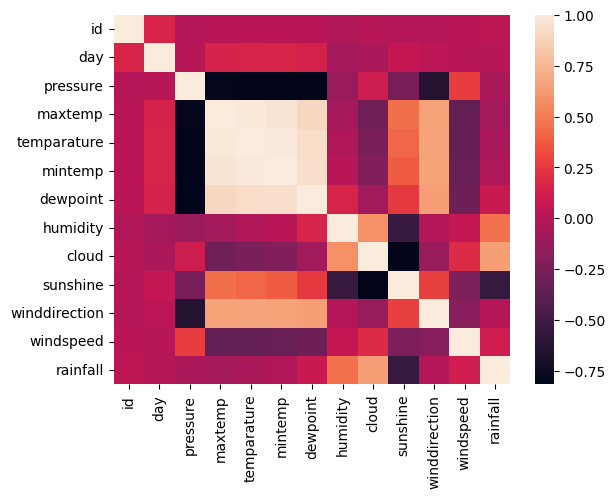

In [7]:
sns.heatmap(data = train_data.corr())

In [8]:
useful_columns = ["pressure", "dewpoint", "humidity", "cloud", "winddirection", "rainfall"]

<Axes: >

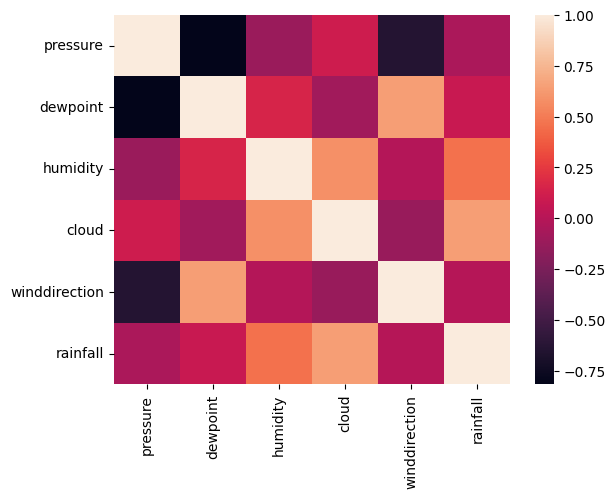

In [9]:
sns.heatmap(data = train_data[useful_columns].corr())

In [10]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
y_train_data = train_data["rainfall"].values

In [12]:
x_train_data = train_data[useful_columns[:-1]].values

In [13]:
x_train_data_scaled = MinMaxScaler().fit_transform(x_train_data)

In [14]:
from sklearn.linear_model import LinearRegression

In [18]:
rain_reg = LinearRegression()

In [19]:
rain_reg.fit(X=x_train_data_scaled,y=y_train_data)

LinearRegression()

In [20]:
y_pred_train_1 = rain_reg.predict(x_train_data_scaled)

In [21]:
y_pred_train_1

array([0.94437875, 0.98116327, 0.18926548, ..., 0.70922187, 0.98945419,
       0.93845154])

In [22]:
from sklearn import metrics

In [24]:
fpr, tpr, thresholds = metrics.roc_curve(y_train_data, y_pred_train_1)

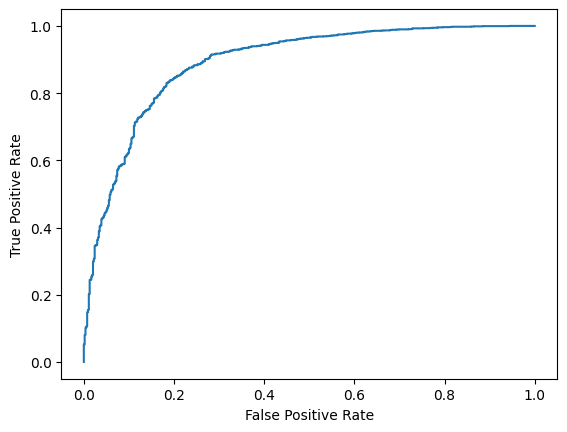

In [27]:
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [28]:
train_score = metrics.roc_auc_score(y_true=y_train_data, y_score=y_pred_train_1)

In [29]:
train_score

0.8905808080808081

In [30]:
rain_reg_2 = LinearRegression()

In [40]:
x_train_data_scaled_2 = MinMaxScaler().fit_transform(train_data.iloc[:,2:-1].values)

In [41]:
rain_reg_2.fit(x_train_data_scaled_2,y_train_data)

LinearRegression()

In [42]:
y_pred_train_2 = rain_reg_2.predict(x_train_data_scaled_2)

In [43]:
metrics.roc_auc_score(y_true=y_train_data, y_score=y_pred_train_2)

0.8955241301907968